# 02 – Gradient descent from scratch

**Goal:** Find `w` and `b` in `price = w × MedInc + b` myself, without scikit-learn.

**Gradient descent:** guess → measure the error → take a small step to lower the error → repeat.
- Height on the hill = the error
- One step = a small change to `w` and `b`
- Bottom = the smallest error

**Data:** only `MedInc` as the feature, so we can see it on a 2D plot. Same split as notebook 01 (80/20, random_state=42).

In [1]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing_df = fetch_california_housing(as_frame=True).frame

X_medinc = housing_df["MedInc"].to_numpy()
y_price = housing_df["MedHouseVal"].to_numpy()

X_train_medinc, X_test_medinc, y_train_price, y_test_price = train_test_split(
    X_medinc, y_price, test_size=0.2, random_state=42
)

print(X_train_medinc.shape, X_test_medinc.shape)

(16512,) (4128,)


## Measuring the error: MSE (Mean Squared Error)

MSE = average of (real − predicted)²
- Squaring makes every error positive, so +2 and −2 don't cancel out to 0.
- Lower MSE = better model. RMSE = √MSE.

Check: on the 2-area example (A: MedInc 8.0, price 4.5 / B: MedInc 2.0, price 1.0)
- w=0, b=0 → MSE = 10.625
- w=0.5, b=0 → MSE = 0.125

In [2]:
def predict_price(medinc, w, b):
    return w * medinc + b

def mean_squared_error_manual(y_real, y_predicted):
    return np.mean((y_real - y_predicted) ** 2)

# Check on the 2-area example
example_medinc = np.array([8.0, 2.0])
example_price = np.array([4.5, 1.0])
print(mean_squared_error_manual(example_price, predict_price(example_medinc, w=0, b=0)))
print(mean_squared_error_manual(example_price, predict_price(example_medinc, w=0.5, b=0)))

# Starting point on the real training data
start_mse = mean_squared_error_manual(y_train_price, predict_price(X_train_medinc, w=0, b=0))
print(f"Start MSE (w=0, b=0): {start_mse:.2f}")

10.625
0.125
Start MSE (w=0, b=0): 5.63


## The gradient: which way is downhill?

The gradient points uphill. We always step the opposite way.
- gradient negative → make w bigger
- gradient positive → make w smaller

gradient_w = −2 × average( MedInc × (real − predicted) )
gradient_b = −2 × average( real − predicted )

Goal: make the ERROR as small as possible (not w).

Check on the 2-area example with w=0, b=0 → gradient_w = −38, gradient_b = −5.5

In [3]:
def compute_gradients(medinc, y_real, w, b):
    error = y_real - predict_price(medinc, w, b)
    gradient_w = -2 * np.mean(medinc * error)
    gradient_b = -2 * np.mean(error)
    return gradient_w, gradient_b

# Check on the 2-area example
print(compute_gradients(example_medinc, example_price, w=0, b=0))

# Gradients at the start on the real training data
start_grad_w, start_grad_b = compute_gradients(X_train_medinc, y_train_price, w=0, b=0)
print(f"Start gradient_w: {start_grad_w:.2f}, gradient_b: {start_grad_b:.2f}")

(np.float64(-38.0), np.float64(-5.5))
Start gradient_w: -19.12, gradient_b: -4.14


## Gradient descent loop

Repeat many times:
1. compute the gradients
2. w = w − learning_rate × gradient_w
3. b = b − learning_rate × gradient_b

- Parameters (the model learns them): w, b
- Hyperparameters (I choose them): learning_rate, n_steps
- If the error GROWS → the learning rate is too big → make it smaller.

In [4]:
learning_rate = 0.01
n_steps = 5000

w, b = 0.0, 0.0
mse_history = []

for step in range(n_steps):
    gradient_w, gradient_b = compute_gradients(X_train_medinc, y_train_price, w, b)
    w = w - learning_rate * gradient_w
    b = b - learning_rate * gradient_b

    mse_history.append(mean_squared_error_manual(y_train_price, predict_price(X_train_medinc, w, b)))

    if step % 1000 == 0:
        print(f"step {step:5d}  w={w:.3f}  b={b:.3f}  MSE={mse_history[-1]:.3f}")

print(f"\nFinal: w={w:.3f}  b={b:.3f}  MSE={mse_history[-1]:.3f}")

step     0  w=0.191  b=0.041  MSE=2.548
step  1000  w=0.421  b=0.436  MSE=0.699
step  2000  w=0.419  b=0.444  MSE=0.699
step  3000  w=0.419  b=0.445  MSE=0.699
step  4000  w=0.419  b=0.445  MSE=0.699

Final: w=0.419  b=0.445  MSE=0.699


## Loss curve

Shows the MSE after each step = my walk down the hill.
- Drops fast at first (steep hill, big gradient)
- Goes flat at the bottom (gradient ≈ 0 → step ≈ 0 → w and b stop changing)
- Result: w = 0.419, b = 0.445, MSE = 0.699

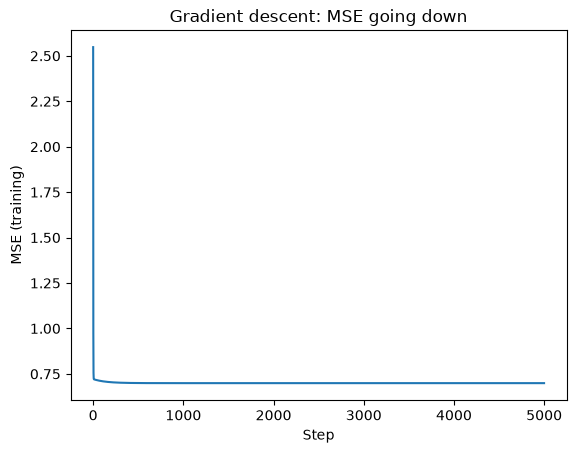

In [5]:
import matplotlib.pyplot as plt

plt.plot(mse_history)
plt.xlabel("Step")
plt.ylabel("MSE (training)")
plt.title("Gradient descent: MSE going down")
plt.show()

## Check against scikit-learn

LinearRegression uses a direct formula (no steps) to find the bottom.
If it gives the same w and b as my gradient descent, my code is correct.

- `.reshape(-1, 1)` → turns the list into a table with 1 column (scikit-learn needs a table).
- Test set NOT used yet. It's used only once, at the end.

In [6]:
from sklearn.linear_model import LinearRegression

sklearn_model = LinearRegression()
sklearn_model.fit(X_train_medinc.reshape(-1, 1), y_train_price)

sklearn_w = sklearn_model.coef_[0]
sklearn_b = sklearn_model.intercept_
sklearn_mse = mean_squared_error_manual(
    y_train_price, predict_price(X_train_medinc, sklearn_w, sklearn_b)
)

print(f"My gradient descent: w={w:.3f}  b={b:.3f}  MSE={mse_history[-1]:.3f}")
print(f"scikit-learn:        w={sklearn_w:.3f}  b={sklearn_b:.3f}  MSE={sklearn_mse:.3f}")

My gradient descent: w=0.419  b=0.445  MSE=0.699
scikit-learn:        w=0.419  b=0.445  MSE=0.699


## Result

- My gradient descent found: w = 0.419, b = 0.445, MSE = 0.699
- scikit-learn found: exactly the same (w = 0.419, b = 0.445, MSE = 0.699), so my code is correct.
- What w = 0.419 means: when MedInc goes up by 1 (= +$10,000 income in the area), the predicted price goes up by 0.419 (= +$41,900).
- Why w and b stopped changing after ~2000 steps: at the bottom of the hill the ground is flat → gradient ≈ 0 → step = learning_rate × 0 ≈ 0 → w and b stay the same.
- What I would change next time: use about 2,000 steps instead of 5,000. Steps 2000–5000 changed almost nothing. (500 is too few: at step 1000, b was still 0.436.)